# 10) — Sampling Controls: Visualizations

Four publication-ready charts for the Module 10 article.  
All figures use the Monday ticket logits `[3.2, 2.8, 0.5]` and the same colour palette.

**Figures:**
1. Temperature effect — how T reshapes the probability distribution
2. Top-k filtering — how kept probabilities are renormalised
3. Top-p nucleus sampling — cumulative threshold determines nucleus size
4. Safe vs Creative profile — same input, different sampling behaviour

Run the **Setup** cell first, then any figure cell independently.

---
## Setup — shared palette, style, and helpers

Run this before any figure cell.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Colour palette ─────────────────────────────────────────────────────────────
PURPLE = '#534AB7'
TEAL   = '#0F6E56'
CORAL  = '#993C1D'
AMBER  = '#BA7517'
RED    = '#A32D2D'
GREEN  = '#1D9E75'
BG     = '#F8F8F6'
TEXT   = '#2C2C2A'
MUTED  = '#73726C'
BORDER = '#D3D1C7'

# Class colours: account_unlock, vpn_issue, security_incident
COLORS = [PURPLE, TEAL, CORAL]

# ── Global rcParams ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.size':          11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.facecolor':     BG,
    'figure.facecolor':   BG,
    'text.color':         TEXT,
    'axes.labelcolor':    TEXT,
    'xtick.color':        MUTED,
    'ytick.color':        MUTED,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
})

# ── Monday ticket logits (from Module 3) ───────────────────────────────────────
LOGITS  = [3.2, 2.8, 0.5]
INTENTS = ['account_unlock', 'vpn_issue', 'security_incident']
SHORT   = ['acct\nunlock', 'vpn\nissue', 'security\nincident']

# ── Helpers ────────────────────────────────────────────────────────────────────
def softmax_temp(logits, T):
    """Apply temperature T to logits and return softmax probabilities."""
    z = np.array(logits, dtype=float) / max(T, 1e-6)
    e = np.exp(z - np.max(z))
    return e / e.sum()

def topk_renorm(probs, k):
    """Keep top-k probabilities, zero out the rest, renormalise."""
    p = np.array(probs, dtype=float)
    idx = np.argsort(p)[::-1]
    mask = np.zeros_like(p)
    mask[idx[:k]] = 1.0
    p_filtered = p * mask
    return p_filtered / p_filtered.sum()

def topp_nucleus(probs, p_thresh):
    """Return nucleus mask for top-p sampling."""
    p = np.array(probs, dtype=float)
    order = np.argsort(p)[::-1]
    cumsum = np.cumsum(p[order])
    nucleus_size = np.searchsorted(cumsum, p_thresh) + 1
    mask = np.zeros_like(p)
    mask[order[:nucleus_size]] = 1.0
    p_filtered = p * mask
    return p_filtered / p_filtered.sum(), mask

def save(fig, filename, dpi=150):
    """Save figure as PNG for blog use. Use dpi=300 for print quality."""
    fig.savefig(filename, dpi=dpi, bbox_inches='tight', facecolor=BG)
    print(f'Saved: {filename}')

print('Setup complete.')
print(f'Monday ticket — original distribution (T=1.0): {softmax_temp(LOGITS, 1.0).round(3)}')

Setup complete.
Monday ticket — original distribution (T=1.0): [0.576 0.386 0.039]


---
## Figure 1 — Temperature effect

Shows how temperature T reshapes the Monday ticket distribution.  
At T=0.3 the model commits hard to `account_unlock`.  
At T=2.0 `security_incident` climbs from 3.9% to 25.4% — dangerous for classification.

Saved: m10_fig1_temperature.png


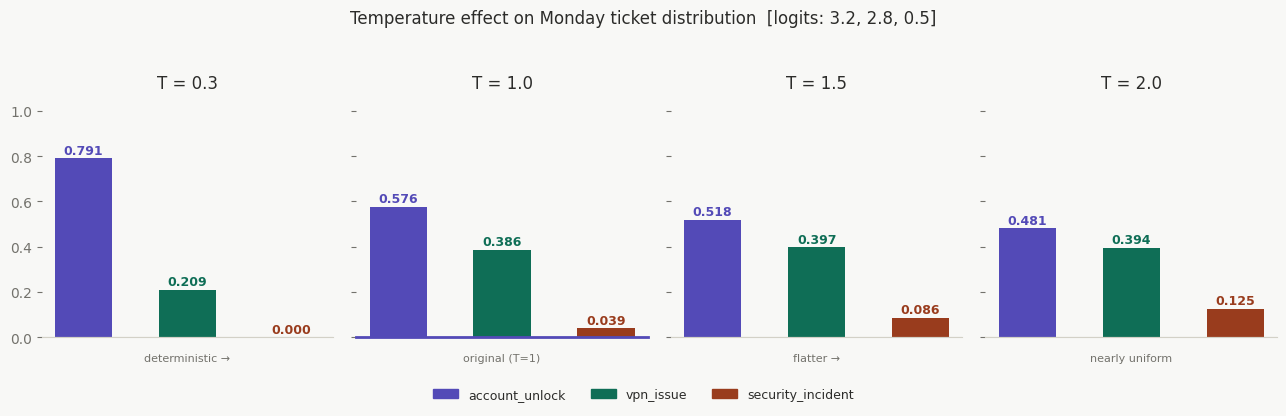

In [2]:
temps       = [0.3, 1.0, 1.5, 2.0]
temp_labels = ['deterministic →', 'original (T=1)', 'flatter →', 'nearly uniform']

fig1, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True)
fig1.patch.set_facecolor(BG)

for ax, T, note in zip(axes, temps, temp_labels):
    ax.set_facecolor(BG)
    probs = softmax_temp(LOGITS, T)

    bars = ax.bar(INTENTS, probs, color=COLORS, width=0.55, zorder=2)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(0, color=BORDER, linewidth=0.8)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color(BORDER)

    for bar, p, c in zip(bars, probs, COLORS):
        ax.text(bar.get_x() + bar.get_width() / 2, p + 0.02,
                f'{p:.3f}', ha='center', fontsize=9,
                fontweight='bold', color=c)

    ax.set_title(f'T = {T}', fontsize=12, fontweight='500', color=TEXT, pad=8)
    ax.text(0.5, -0.10, note, ha='center', transform=ax.transAxes,
            fontsize=8, color=MUTED)

# Highlight the original distribution panel
axes[1].spines['bottom'].set_color(PURPLE)
axes[1].spines['bottom'].set_linewidth(2)

# Legend
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, INTENTS)]
fig1.legend(handles=patches, loc='lower center', ncol=3,
            fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.08))

fig1.suptitle(
    'Temperature effect on Monday ticket distribution  [logits: 3.2, 2.8, 0.5]',
    fontsize=12, fontweight='500', color=TEXT, y=1.04
)
fig1.tight_layout(w_pad=1.5)
save(fig1, 'm10_fig1_temperature.png')
plt.show()

---
## Figure 2 — Top-k filtering and renormalisation

Shows how top-k restricts the candidate set and renormalises remaining probabilities.  
At k=1 the output is fully deterministic — equivalent to argmax.

Saved: m10_fig2_topk.png


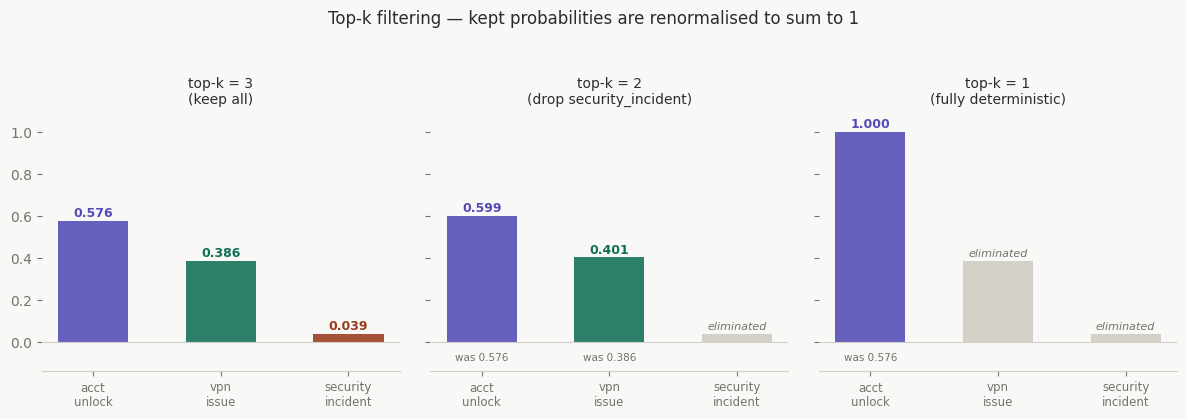

In [3]:
probs_orig = softmax_temp(LOGITS, 1.0)   # [0.576, 0.386, 0.039]
ks         = [3, 2, 1]
k_titles   = [
    'top-k = 3\n(keep all)',
    'top-k = 2\n(drop security_incident)',
    'top-k = 1\n(fully deterministic)',
]

fig2, axes = plt.subplots(1, 3, figsize=(12, 4.0), sharey=True)
fig2.patch.set_facecolor(BG)

for ax, k, title in zip(axes, ks, k_titles):
    ax.set_facecolor(BG)
    renorm = topk_renorm(probs_orig, k)

    for i, (p_orig, p_new, c) in enumerate(zip(probs_orig, renorm, COLORS)):
        if p_new == 0:
            # Eliminated bar
            ax.bar(i, p_orig, color=BORDER, width=0.55, zorder=2)
            ax.text(i, p_orig + 0.02, 'eliminated',
                    ha='center', fontsize=8, color=MUTED, style='italic')
        else:
            # Kept bar
            ax.bar(i, p_new, color=c, width=0.55, zorder=2, alpha=0.88)
            ax.text(i, p_new + 0.02, f'{p_new:.3f}',
                    ha='center', fontsize=9, fontweight='bold', color=c)
            if abs(p_new - p_orig) > 0.005:
                ax.text(i, -0.09, f'was {p_orig:.3f}',
                        ha='center', fontsize=7.5, color=MUTED)

    ax.set_xticks(range(3))
    ax.set_xticklabels(SHORT, fontsize=8.5)
    ax.set_ylim(-0.14, 1.08)
    ax.set_title(title, fontsize=10, fontweight='500', color=TEXT, pad=8)
    ax.axhline(0, color=BORDER, linewidth=0.8)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color(BORDER)

fig2.suptitle(
    'Top-k filtering — kept probabilities are renormalised to sum to 1',
    fontsize=12, fontweight='500', color=TEXT, y=1.04
)
fig2.tight_layout(w_pad=2)
save(fig2, 'm10_fig2_topk.png')
plt.show()

---
## Figure 3 — Top-p nucleus sampling

The dashed amber line shows the cumulative probability sum.  
The horizontal dotted line is the threshold p.  
The nucleus is the smallest set of classes whose cumulative sum crosses that threshold.

Saved: m10_fig3_topp.png


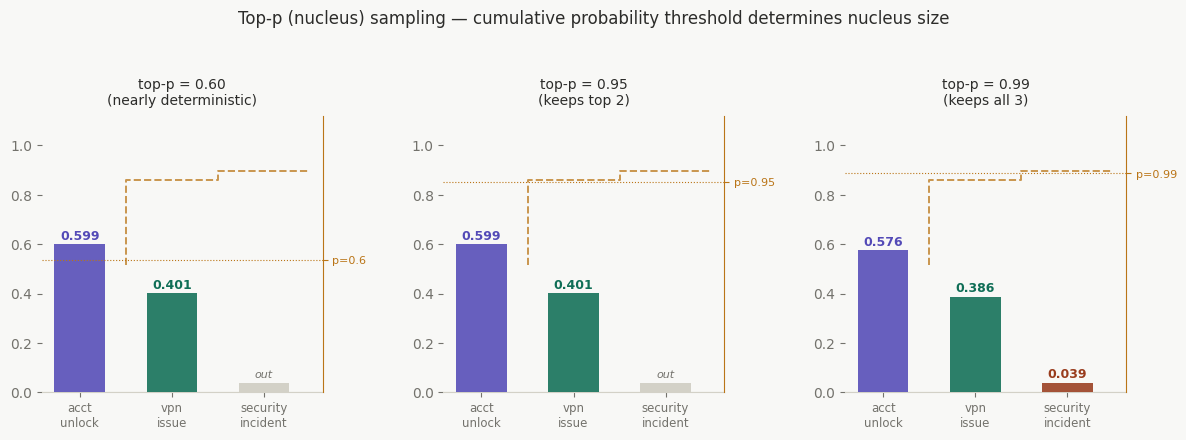

In [4]:
probs_orig = softmax_temp(LOGITS, 1.0)   # sorted descending: [0.576, 0.386, 0.039]
p_thresholds = [0.60, 0.95, 0.99]
p_titles     = [
    'top-p = 0.60\n(nearly deterministic)',
    'top-p = 0.95\n(keeps top 2)',
    'top-p = 0.99\n(keeps all 3)',
]

fig3, axes = plt.subplots(1, 3, figsize=(12, 4.2))
fig3.patch.set_facecolor(BG)

for ax, p_thresh, title in zip(axes, p_thresholds, p_titles):
    ax.set_facecolor(BG)
    renorm, mask = topp_nucleus(probs_orig, p_thresh)
    cumsum = np.cumsum(probs_orig)   # for plotting

    # Cumulative sum line on twin axis
    ax2 = ax.twinx()
    ax2.set_facecolor(BG)
    ax2.step(np.arange(3) + 0.5, cumsum, where='pre',
             color=AMBER, linewidth=1.4, linestyle='--', alpha=0.75)
    ax2.axhline(p_thresh, color=AMBER, linewidth=0.8, linestyle=':')
    ax2.set_ylim(0, 1.25)
    ax2.set_yticks([p_thresh])
    ax2.set_yticklabels([f'p={p_thresh}'], fontsize=8, color=AMBER)
    ax2.spines['right'].set_visible(True)
    ax2.spines['right'].set_color(AMBER)
    ax2.spines['top'].set_visible(False)
    ax2.tick_params(right=True, colors=AMBER)

    # Bars
    for i, (p_orig, p_new, c, m) in enumerate(zip(probs_orig, renorm, COLORS, mask)):
        if m == 0:
            ax.bar(i, p_orig, color=BORDER, width=0.55, zorder=2)
            ax.text(i, p_orig + 0.02, 'out',
                    ha='center', fontsize=8, color=MUTED, style='italic')
        else:
            ax.bar(i, p_new, color=c, width=0.55, zorder=3, alpha=0.88)
            ax.text(i, p_new + 0.02, f'{p_new:.3f}',
                    ha='center', fontsize=9, fontweight='bold', color=c)

    ax.set_xticks(range(3))
    ax.set_xticklabels(SHORT, fontsize=8.5)
    ax.set_ylim(0, 1.12)
    ax.set_title(title, fontsize=10, fontweight='500', color=TEXT, pad=8)
    ax.axhline(0, color=BORDER, linewidth=0.8)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color(BORDER)

fig3.suptitle(
    'Top-p (nucleus) sampling — cumulative probability threshold determines nucleus size',
    fontsize=12, fontweight='500', color=TEXT, y=1.04
)
fig3.tight_layout(w_pad=2.5)
save(fig3, 'm10_fig3_topp.png')
plt.show()

---
## Figure 4 — Safe vs Creative profile

Same Monday ticket input, two different sampling profiles.  
Safe (left) collapses to near-certain `account_unlock`.  
Creative (right) preserves the original distribution for varied draft generation.

In [ ]:
fig4, axes = plt.subplots(1, 2, figsize=(11, 4.2))
fig4.patch.set_facecolor(BG)

profile_specs = [
    dict(label='Safe profile',
         T=0.01,
         desc='T = 0  ·  top-k = 1  ·  deterministic',
         use='Classification · routing · audit logs',
         col=TEAL),
    dict(label='Creative profile',
         T=1.0,
         desc='T = 1.0  ·  top-k = 50  ·  top-p = 0.92',
         use='Draft responses · clarification questions',
         col=PURPLE),
]

for ax, spec in zip(axes, profile_specs):
    ax.set_facecolor(BG)
    probs = softmax_temp(LOGITS, spec['T'])

    bars = ax.bar(range(3), probs, color=spec['col'],
                  width=0.55, zorder=2, alpha=0.85)
    ax.set_ylim(0, 1.12)
    ax.set_xticks(range(3))
    ax.set_xticklabels(SHORT, fontsize=9)
    ax.axhline(0, color=BORDER, linewidth=0.8)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color(BORDER)

    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, p + 0.02,
                f'{p:.3f}', ha='center', fontsize=10,
                fontweight='bold', color=spec['col'])

    ax.set_title(spec['label'], fontsize=13, fontweight='600',
                 color=spec['col'], pad=10)
    ax.text(0.5, -0.14, spec['desc'],
            ha='center', transform=ax.transAxes, fontsize=9, color=MUTED)
    ax.text(0.5, -0.22, spec['use'],
            ha='center', transform=ax.transAxes, fontsize=8.5,
            color=TEXT, style='italic')

fig4.suptitle(
    'Safe vs Creative profile — same input, different sampling behaviour',
    fontsize=12, fontweight='500', color=TEXT, y=1.04
)
fig4.tight_layout(w_pad=3)
save(fig4, 'm10_fig4_profiles.png')
plt.show()

---
## Bonus — Interactive temperature explorer

Try any temperature value and see the resulting distribution instantly.

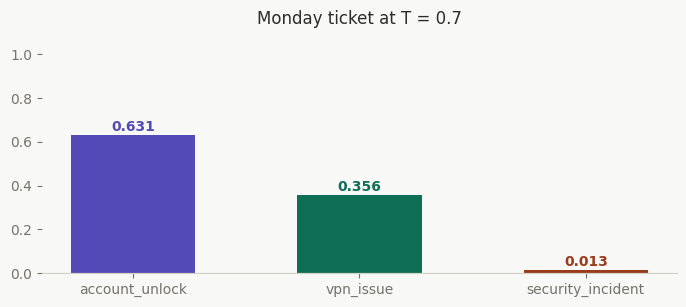


T = 0.7
  account_unlock         0.6306
  vpn_issue              0.3561
  security_incident      0.0133
  Sum: 1.000000


In [5]:
# Change T_EXPLORE to any value and re-run this cell
T_EXPLORE = 0.7   # try: 0.1, 0.5, 1.0, 1.5, 2.0, 3.0

probs = softmax_temp(LOGITS, T_EXPLORE)

fig_e, ax_e = plt.subplots(figsize=(7, 3.2))
fig_e.patch.set_facecolor(BG)
ax_e.set_facecolor(BG)

bars = ax_e.bar(INTENTS, probs, color=COLORS, width=0.55, zorder=2)
ax_e.set_ylim(0, 1.1)
ax_e.set_xticks(range(3))
ax_e.set_xticklabels(INTENTS, fontsize=10)
ax_e.axhline(0, color=BORDER, linewidth=0.8)
ax_e.spines['bottom'].set_visible(True)
ax_e.spines['bottom'].set_color(BORDER)

for bar, p, c in zip(bars, probs, COLORS):
    ax_e.text(bar.get_x() + bar.get_width() / 2, p + 0.02,
              f'{p:.3f}', ha='center', fontsize=10, fontweight='bold', color=c)

ax_e.set_title(f'Monday ticket at T = {T_EXPLORE}', fontsize=12,
               fontweight='500', color=TEXT)
fig_e.tight_layout()
plt.show()

print(f'\nT = {T_EXPLORE}')
for intent, p in zip(INTENTS, probs):
    print(f'  {intent:<22} {p:.4f}')
print(f'  Sum: {probs.sum():.6f}')